In [95]:
import pandas as pd
import missingno as msno
import matplotlib.pyplot as plt

# Reading

In [96]:
df_online_raw = pd.read_csv('../data/online_shoppers_intention.csv')
print(df_online_raw.shape)
df_online_raw.head()

(12330, 18)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [97]:
df_online_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

# Preprocessing

## Duplicated

In [98]:
df_online_raw.duplicated().sum()

125

In [99]:
df_online_raw[
    df_online_raw.duplicated(keep=False)
].sort_values(
    list(df_online_raw.columns)
).head(10)

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
8247,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,1,1,1,1,Returning_Visitor,True,False
10751,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,1,1,1,1,Returning_Visitor,True,False
11658,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,1,1,1,1,Returning_Visitor,True,False
8882,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,1,1,1,2,New_Visitor,False,False
11934,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,1,1,1,2,New_Visitor,False,False
11110,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,1,1,1,3,Returning_Visitor,False,False
12159,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,1,1,1,3,Returning_Visitor,False,False
10341,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,1,1,4,1,Returning_Visitor,True,False
11801,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,1,1,4,1,Returning_Visitor,True,False
11938,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,1,1,4,1,Returning_Visitor,True,False


In [100]:
print(df_online_raw.shape)

df_online_preproc = (
    df_online_raw
    .drop_duplicates()
    .reset_index(drop=True)
    .copy()
)

print(df_online_preproc.shape)

(12330, 18)
(12205, 18)


## Missing Values

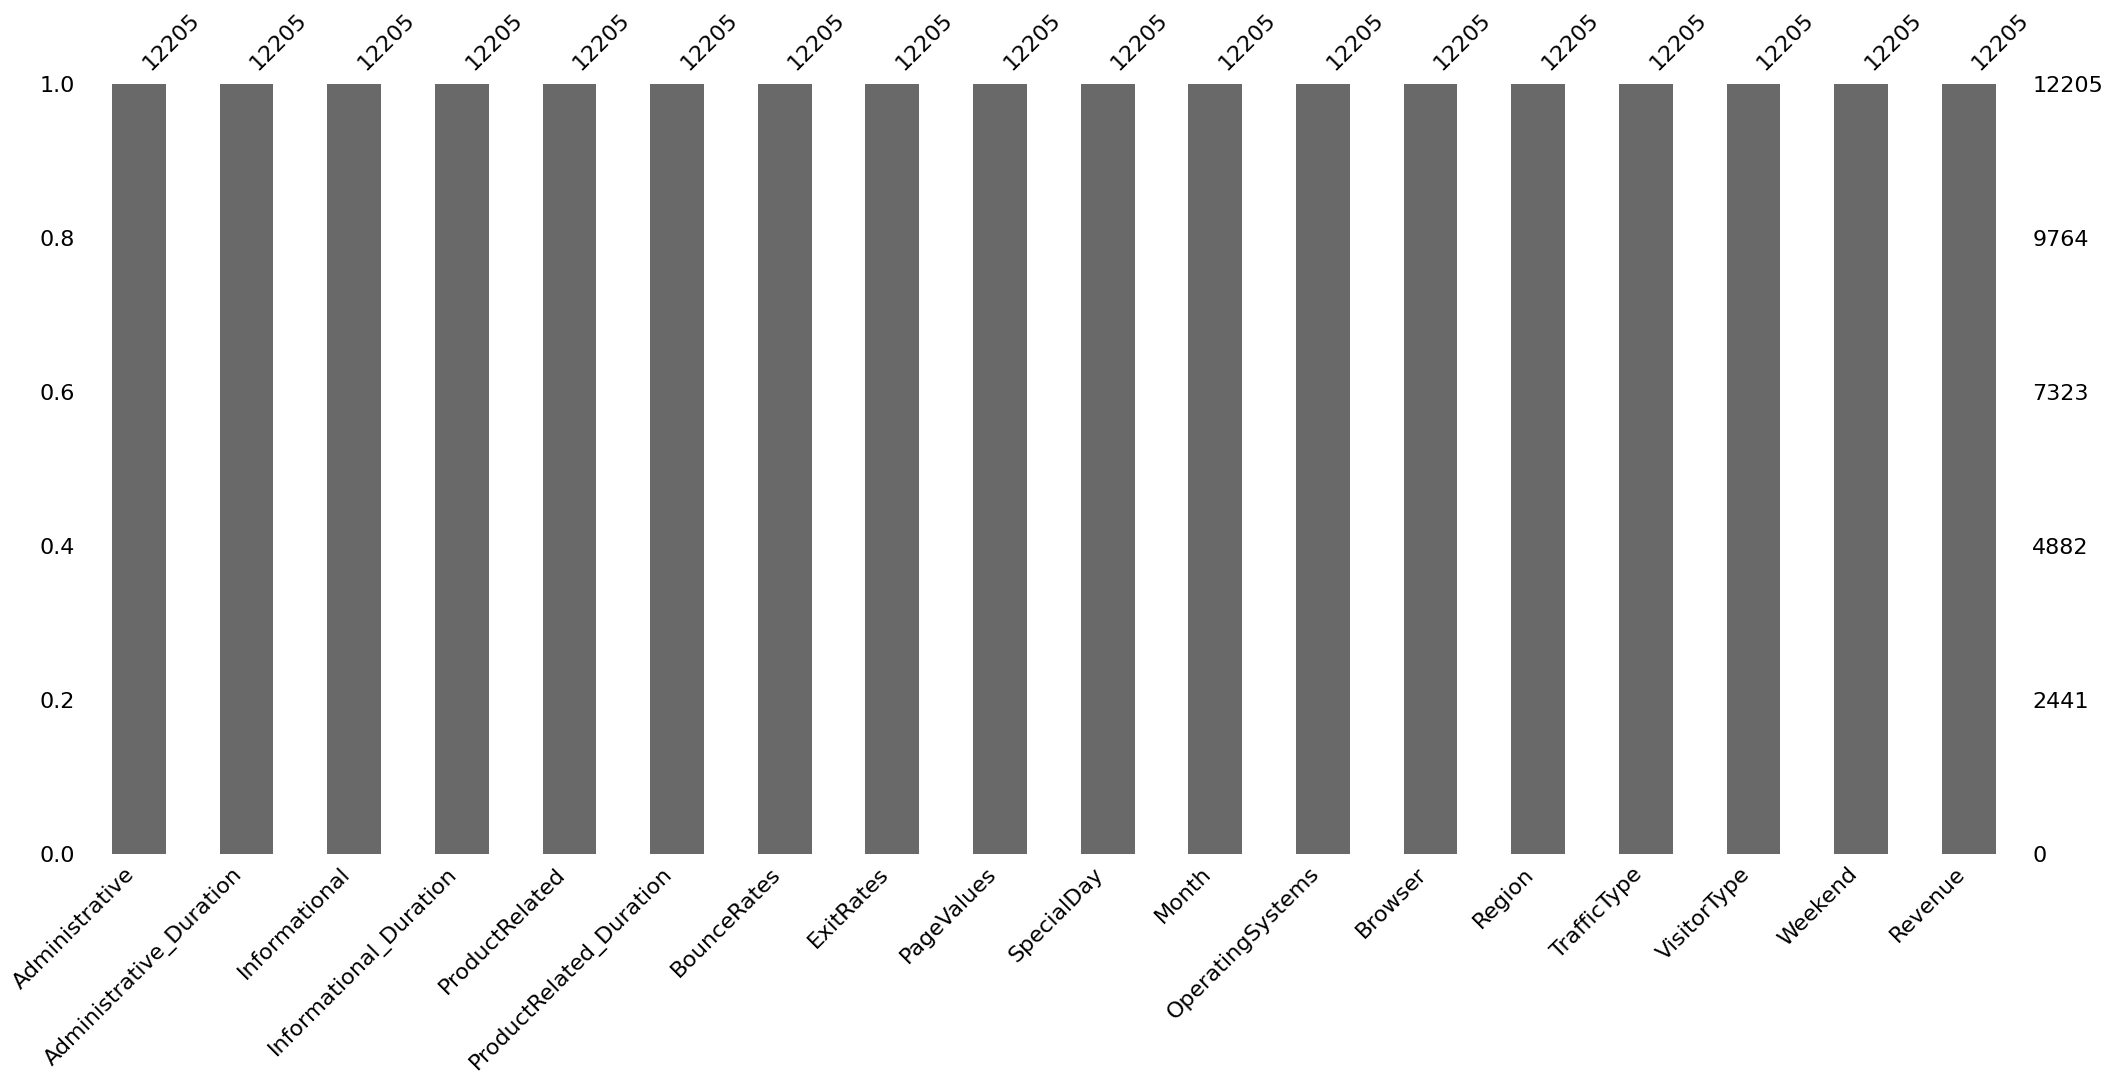

In [101]:
msno.bar(df_online_preproc)
plt.show()

## Casting

In [102]:
df_online_preproc['Revenue'].value_counts()

Revenue
False    10297
True      1908
Name: count, dtype: int64

In [103]:
df_online_preproc['Weekend'].value_counts()

Weekend
False    9346
True     2859
Name: count, dtype: int64

In [104]:
df_online_preproc['Revenue'] = df_online_preproc['Revenue'].map({True: 1, False: 0})
df_online_preproc['Revenue'].value_counts()

Revenue
0    10297
1     1908
Name: count, dtype: int64

In [105]:
df_online_preproc['Weekend'] = df_online_preproc['Weekend'].map({True: 1, False: 0})
df_online_preproc['Weekend'].value_counts()

Weekend
0    9346
1    2859
Name: count, dtype: int64

In [106]:
cat_cols = ['OperatingSystems', 'Browser', 'Region', 'TrafficType']

prefixes = {
    'OperatingSystems': 'OS',
    'Browser': 'Browser',
    'Region': 'Region',
    'TrafficType': 'Traffic',
}

for col in cat_cols:
    df_online_preproc[col] = df_online_preproc[col].astype(str).apply(lambda x: f'{prefixes[col]}_{x}')

In [107]:
df_online_preproc[cat_cols].head()

,OperatingSystems,Browser,Region,TrafficType
0,OS_1,Browser_1,Region_1,Traffic_1
1,OS_2,Browser_2,Region_1,Traffic_2
2,OS_4,Browser_1,Region_9,Traffic_3
3,OS_3,Browser_2,Region_2,Traffic_4
4,OS_3,Browser_3,Region_1,Traffic_4


# Feature Engineering

In [108]:
df_online_preproc['total_pages'] = df_online_preproc['Administrative'] + df_online_preproc['Informational'] + df_online_preproc['ProductRelated']
df_online_preproc['total_duration'] = df_online_preproc['Administrative_Duration'] + df_online_preproc['Informational_Duration'] + df_online_preproc['ProductRelated_Duration']
df_online_preproc['product_related_ratio'] = df_online_preproc['ProductRelated'] / df_online_preproc['total_pages'].replace(0, float('nan'))
df_online_preproc['avg_time_per_page'] = df_online_preproc['total_duration'] / df_online_preproc['total_pages'].replace(0, float('nan'))

## binarización
df_online_preproc['is_special_period'] = (df_online_preproc['SpecialDay'] > 0).astype(int)

df_online_preproc[['total_pages', 'total_duration', 'product_related_ratio', 'avg_time_per_page', 'is_special_period']].head()

,total_pages,total_duration,product_related_ratio,avg_time_per_page,is_special_period
0,1,0.000000,1.0,0.000000,0
1,2,64.000000,1.0,32.000000,0
2,1,0.000000,1.0,0.000000,0
3,2,2.666667,1.0,1.333333,0
4,10,627.500000,1.0,62.750000,0


# Saving

In [109]:
df_online_preproc.dtypes

Administrative               int64
Administrative_Duration    float64
Informational                int64
Informational_Duration     float64
ProductRelated               int64
ProductRelated_Duration    float64
BounceRates                float64
ExitRates                  float64
PageValues                 float64
SpecialDay                 float64
Month                       object
OperatingSystems            object
Browser                     object
Region                      object
TrafficType                 object
VisitorType                 object
Weekend                      int64
Revenue                      int64
total_pages                  int64
total_duration             float64
product_related_ratio      float64
avg_time_per_page          float64
is_special_period            int32
dtype: object

In [110]:
df_online_preproc.to_csv('../data/online_shoppers_preproc.csv', index=False)